# Classical vs Quantum Database Search Comparison

This notebook compares a classical linear search with a quantum search algorithm using Grover's method. We use a larger dataset and collect statistics to show the difference in operations and success behavior.

The classical search checks values one-by-one. The quantum search uses superposition and interference to make the correct answer more likely.

Checking index 0000 -> Alice
Checking index 0001 -> Bob
Checking index 0010 -> Charlie
Checking index 0011 -> David
Checking index 0100 -> Emma
Checking index 0101 -> Frank
Checking index 0110 -> Grace

CLASSICAL SEARCH RESULT
Database Size: 16
Target Name: Grace
Found Index: 0110
Operations Required: 7

QUANTUM SEARCH RESULT
Dataset Size: 16
Target State: 0110
Most Likely State: 0110
Database Record: Grace
Grover Success Rate: 0.9658203125
Estimated Grover Iterations: 3


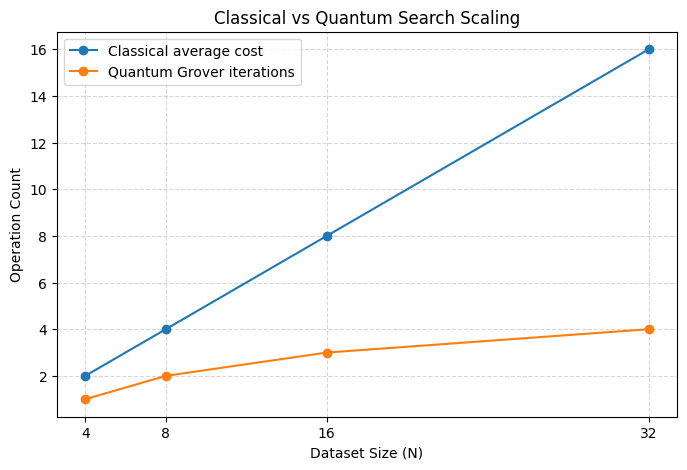

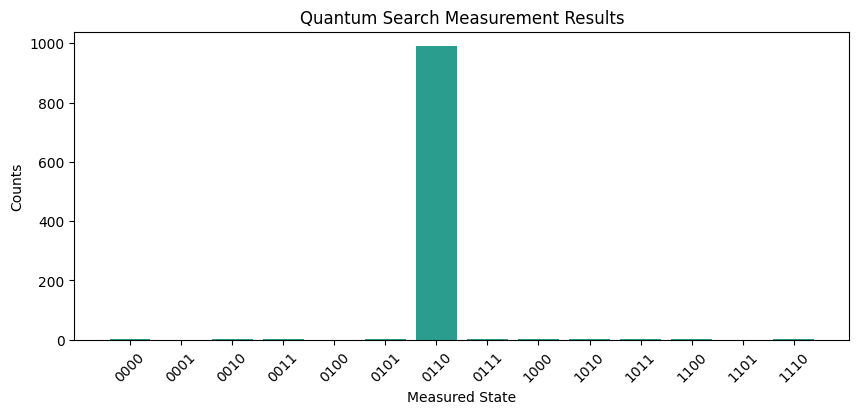


Data used for comparison:
N=4: classical ~2.0, quantum ~1
N=8: classical ~4.0, quantum ~2
N=16: classical ~8.0, quantum ~3
N=32: classical ~16.0, quantum ~4


In [5]:
# ==========================================================
# CLASSICAL DATABASE SEARCH
# ==========================================================

# Larger dataset of 16 entries for a stronger comparison
names = [
    "Alice", "Bob", "Charlie", "David",
    "Emma", "Frank", "Grace", "Henry",
    "Irene", "Jack", "Karen", "Leo",
    "Mia", "Nate", "Olivia", "Paul"
]

database = {format(i, '04b'): names[i] for i in range(len(names))}

target_name = "Grace"

# ----------------------------------------------------------
# Classical Linear Search
# ----------------------------------------------------------

operations = 0
found_key = None

for key, value in database.items():
    operations += 1
    print(f"Checking index {key} -> {value}")
    if value == target_name:
        found_key = key
        break

print("\nCLASSICAL SEARCH RESULT")
print("Database Size:", len(database))
print("Target Name:", target_name)
print("Found Index:", found_key)
print("Operations Required:", operations)

# Compute average classical cost for comparison
average_classical_cost = sum(i + 1 for i in range(len(database))) / len(database)

# ==========================================================
# QUANTUM DATABASE SEARCH USING GROVER'S ALGORITHM
# ==========================================================

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt

# Choose the target state based on the database lookup
target_state = [key for key, value in database.items() if value == target_name][0]

n_qubits = 4
N = 2**n_qubits

qc = QuantumCircuit(n_qubits, n_qubits)

# ----------------------------------------------------------
# STEP 1: SUPERPOSITION
# ----------------------------------------------------------

qc.h(range(n_qubits))

# ----------------------------------------------------------
# ORACLE
# ----------------------------------------------------------

def oracle(qc, target_state):
    for idx, bit in enumerate(target_state):
        if bit == '0':
            qc.x(idx)

    qc.h(n_qubits - 1)
    qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)
    qc.h(n_qubits - 1)

    for idx, bit in enumerate(target_state):
        if bit == '0':
            qc.x(idx)

# ----------------------------------------------------------
# DIFFUSER
# ----------------------------------------------------------

def diffuser(qc):
    qc.h(range(n_qubits))
    qc.x(range(n_qubits))
    qc.h(n_qubits - 1)
    qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)
    qc.h(n_qubits - 1)
    qc.x(range(n_qubits))
    qc.h(range(n_qubits))

# ----------------------------------------------------------
# GROVER ITERATIONS
# ----------------------------------------------------------

iterations = int(np.floor((np.pi / 4) * np.sqrt(N)))

for _ in range(iterations):
    oracle(qc, target_state)
    diffuser(qc)

# ----------------------------------------------------------
# MEASURE
# ----------------------------------------------------------

qc.measure(range(n_qubits), range(n_qubits))

# ----------------------------------------------------------
# RUN
# ----------------------------------------------------------

simulator = AerSimulator()
compiled = transpile(qc, simulator)
job = simulator.run(compiled, shots=1024)
result = job.result()
counts = result.get_counts()

most_likely_state = max(counts, key=counts.get)
quantum_success_rate = counts.get(target_state, 0) / 1024

print("\nQUANTUM SEARCH RESULT")
print("Dataset Size:", N)
print("Target State:", target_state)
print("Most Likely State:", most_likely_state)
print("Database Record:", database[most_likely_state])
print("Grover Success Rate:", quantum_success_rate)
print("Estimated Grover Iterations:", iterations)

# ----------------------------------------------------------
# COLLECT DATA FOR PLOT
# ----------------------------------------------------------

dataset_sizes = [4, 8, 16, 32]
classical_costs = [size / 2 for size in dataset_sizes]
quantum_costs = [np.floor((np.pi / 4) * np.sqrt(size)) for size in dataset_sizes]

plt.figure(figsize=(8, 5))
plt.plot(dataset_sizes, classical_costs, marker='o', label='Classical average cost')
plt.plot(dataset_sizes, quantum_costs, marker='o', label='Quantum Grover iterations')
plt.xlabel('Dataset Size (N)')
plt.ylabel('Operation Count')
plt.title('Classical vs Quantum Search Scaling')
plt.xticks(dataset_sizes)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

labels = sorted(counts.keys())
values = [counts[label] for label in labels]

plt.figure(figsize=(10, 4))
plt.bar(labels, values, color='#2a9d8f')
plt.xlabel('Measured State')
plt.ylabel('Counts')
plt.title('Quantum Search Measurement Results')
plt.xticks(rotation=45)
plt.show()

print("\nData used for comparison:")
for size, c_cost, q_cost in zip(dataset_sizes, classical_costs, quantum_costs):
    print(f"N={size}: classical ~{c_cost:.1f}, quantum ~{int(q_cost)}")


## Classical Cost vs Actual Quantum Success Probability

This plot shows the classical search time scaling together with the actual measured quantum Grover success probability for the current dataset. It helps compare how quantum measurement quality relates to classical operation cost.

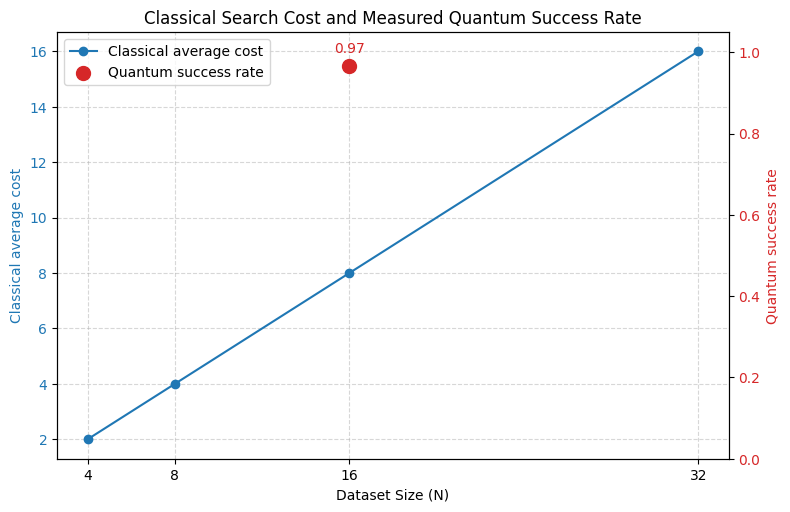

In [6]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(dataset_sizes, classical_costs, marker='o', color='tab:blue', label='Classical average cost')
ax1.set_xlabel('Dataset Size (N)')
ax1.set_ylabel('Classical average cost', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticks(dataset_sizes)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
ax2.scatter([N], [quantum_success_rate], color='tab:red', s=100, label='Quantum success rate')
ax2.set_ylabel('Quantum success rate', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0, 1.05)

for x, y in [(N, quantum_success_rate)]:
    ax2.annotate(f'{y:.2f}', xy=(x, y), xytext=(0, 10), textcoords='offset points', ha='center', color='tab:red')

fig.tight_layout()
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')
plt.title('Classical Search Cost and Measured Quantum Success Rate')
plt.show()